Attention!!!
Loaded 453 parameters!
Over!!!
모델 세팅 완료


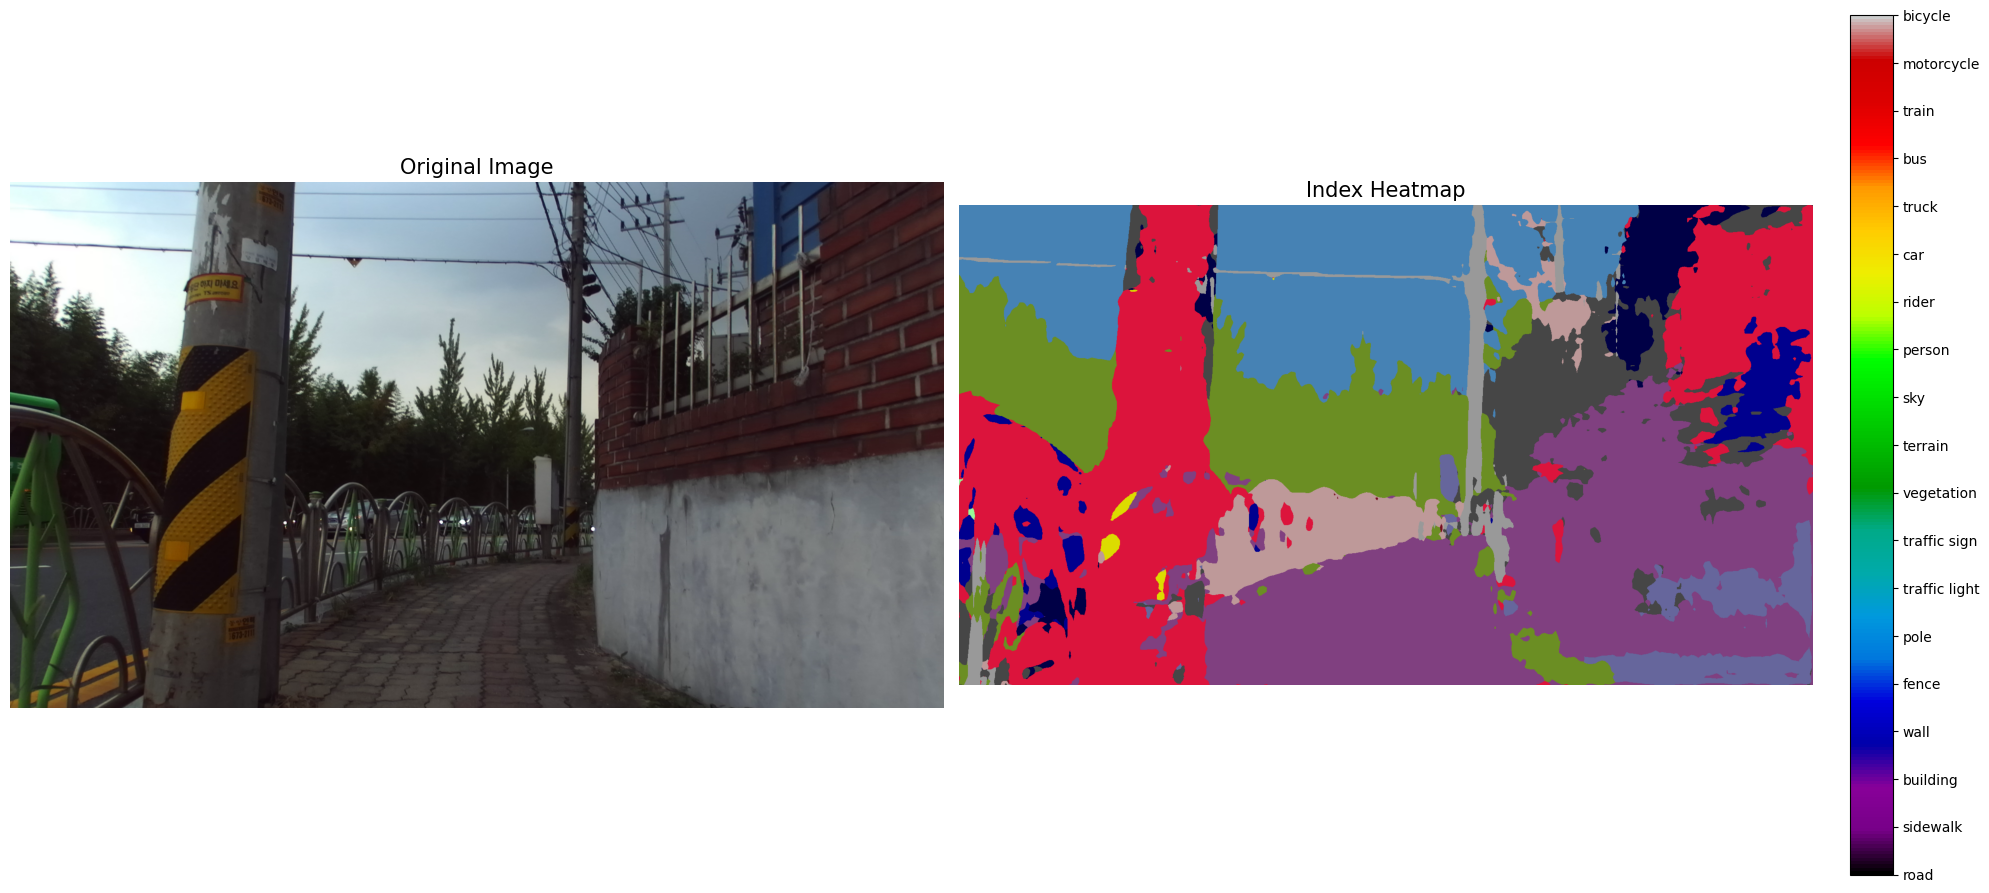

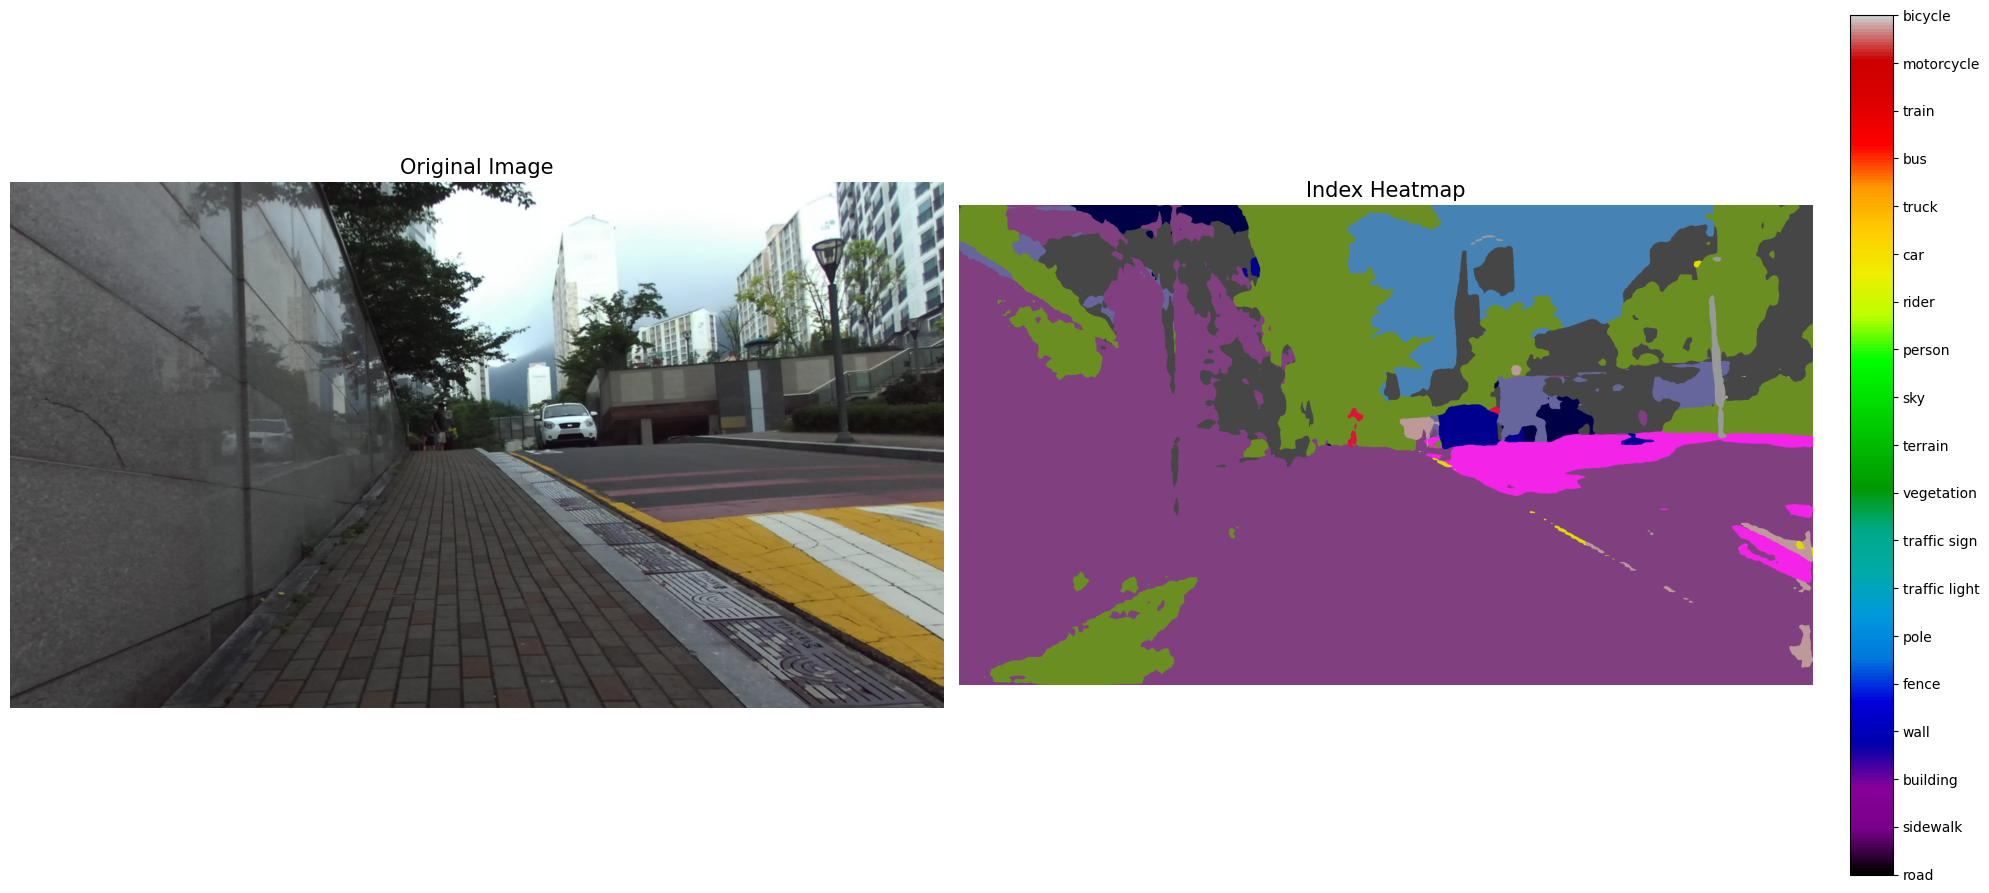

In [9]:
import numpy as np
import torch

from lib.utils.path import raw_data_path
from v2.heatmap import compare_results
from v2.pidnet_torch_predictor import create_model, postprocess_output, preprocess_image

# mean = [0.485, 0.456, 0.406]
# std = [0.229, 0.224, 0.225]

color_map = [
    (128, 64, 128),
    (244, 35, 232),
    (70, 70, 70),
    (102, 102, 156),
    (190, 153, 153),
    (153, 153, 153),
    (250, 170, 30),
    (220, 220, 0),
    (107, 142, 35),
    (152, 251, 152),
    (70, 130, 180),
    (220, 20, 60),
    (255, 0, 0),
    (0, 0, 142),
    (0, 0, 70),
    (0, 60, 100),
    (0, 80, 100),
    (0, 0, 230),
    (119, 11, 32),
]

model = create_model()

image_names = ['ZED1_KSC_001032', 'ZED4_KSC_010545']
foder_nums = ['001', '007']

with torch.no_grad():
    for _, (name, num) in enumerate(list(zip(image_names, foder_nums, strict=False))):
        folder_path = raw_data_path(num)
        conf_file = folder_path / f'Depth_{num}.conf'
        img_path = folder_path / f'{name}_L.png'
        conf_img = folder_path / f'{name}_confidence.png'
        disp_img = folder_path / f'{name}_disp16.png'

        # disp_map = cv2.imread(str(disp_img), cv2.IMREAD_UNCHANGED).astype(np.float32)
        # conf_map = (
        #     cv2.imread(str(conf_img), cv2.IMREAD_UNCHANGED).astype(np.float32) / 255.0
        # )

        input_tensor, org_size = preprocess_image(img_path, device='cuda')

        # --- 추론 ---
        output = model(input_tensor)

        # --- 후처리 (인덱스 맵 생성) ---
        pred_index = postprocess_output(output, org_size)

        # --- 시각화 (Color Mapping) ---
        # 기존의 이중 for문보다 numpy 인덱싱을 쓰는 것이 훨씬 빠릅니다.
        sv_img = np.zeros((org_size[0], org_size[1], 3), dtype=np.uint8)
        for i, color in enumerate(color_map):
            sv_img[pred_index == i] = color

        # --- 저장 ---
        # img_name = os.path.basename(img_path)
        # Image.fromarray(sv_img).save(os.path.join(output_path(), img_name))
        compare_results(img_path, sv_img)
